# Team project template
Шаблон для командной защиты.

In [1]:
from pathlib import Path
import os, sys
PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / "outputs" / "mplconfig"))
(PROJECT / "outputs").mkdir(exist_ok=True)
(PROJECT / "outputs" / "mplconfig").mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solar_neutrino.fluxes import load_flux_table, plot_fluxes
from solar_neutrino.spectra import load_b8_spectrum, normalize_spectrum
from solar_neutrino.oscillations import OscillationParameters, compute_survival_probability_grid

## Select task

In [2]:
task = "solar_sources"  # solar_sources, msw, detector, statistics
team_name = "Team X"
print(team_name, task)

Team X solar_sources


## Load data

In [3]:
fluxes = load_flux_table(PROJECT / "data" / "solar_fluxes_reference.csv")
E_b8, b8_shape = load_b8_spectrum(PROJECT / "data" / "b8_spectrum.csv")
b8_shape = normalize_spectrum(E_b8, b8_shape)
fluxes.head()

,source,flux_cm2_s,kind,comment
0,pp,5.980000e+10,continuum,pp-chain dominant flux
1,pep,1.440000e+08,line,monoenergetic
2,hep,7.980000e+03,continuum,rare high-energy tail
3,Be7,4.930000e+09,line,electron capture lines
4,B8,5.460000e+06,continuum,important for water Cherenkov detectors


## Produce plots

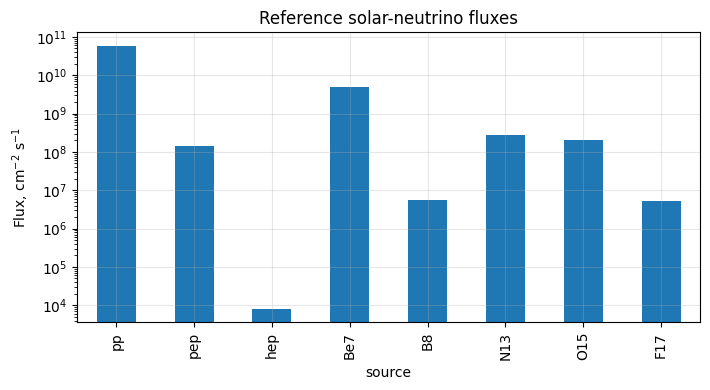

/Users/dmitrijnaumov/Documents/NeutrinoHit/talks/solar-neutrino-masterclass/outputs/Team_X_solar_sources.png


In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
if task == "solar_sources":
    plot_fluxes(fluxes, ax=ax)
elif task == "msw":
    E_grid = np.linspace(0.1, 15.0, 200)
    ax.plot(E_grid, compute_survival_probability_grid(E_grid, OscillationParameters()))
    ax.set_xlabel(r"$E_\nu$, MeV"); ax.set_ylabel(r"$P_{ee}$")
else:
    ax.plot(E_b8, b8_shape)
    ax.set_xlabel(r"$E_\nu$, MeV"); ax.set_ylabel("normalized shape")
ax.grid(alpha=0.3); fig.tight_layout()
outfile = PROJECT / "outputs" / (team_name.replace(" ", "_") + "_" + task + ".png")
fig.savefig(outfile, dpi=160); plt.show(); print(outfile)

## Short conclusion

In [5]:
conclusion = "Write one specific physics conclusion here."
print(conclusion)

Write one specific physics conclusion here.
